In [143]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model ,Sequential
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D
from tensorflow.keras.layers import MaxPooling2D, concatenate, Dense, Flatten ,UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [144]:
Size = (256, 256)
mask_files = glob('../datasets/kaggle_3m/*/*_mask*')
train_files = [file.replace('_mask', '') for file in mask_files]

In [145]:
train_files[:5]

['../datasets/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_10.tif',
 '../datasets/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_11.tif',
 '../datasets/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_12.tif',
 '../datasets/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_13.tif',
 '../datasets/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_14.tif']

In [146]:
def label(mask):
    value = np.max(cv2.imread(mask))
    return '1' if value > 0 else '0'
df = pd.DataFrame({"image": train_files,
                   "mask": mask_files,
                  "label":[label(x) for x in mask_files]})

In [147]:
df.head()

,image,mask,label
0,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,0
1,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,1
2,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,1
3,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,1
4,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,../datasets/kaggle_3m\TCGA_CS_4941_19960909\TC...,1


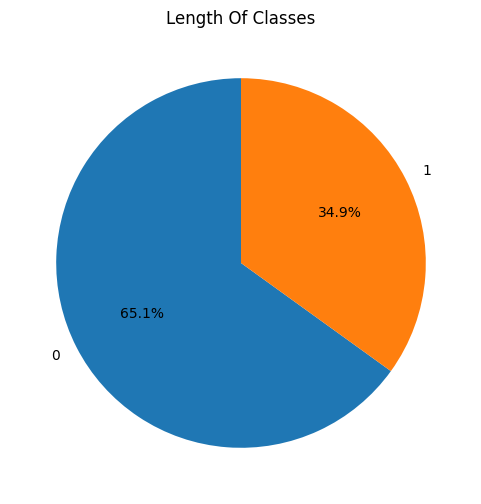

In [148]:
class_counts = df['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Length Of Classes')
plt.show()

In [149]:
df_Tumor = df[df['label']=='1'].sample(5).values
df_NotTumor = df[df['label']=='0'].sample(5).values

In [150]:
df_Tumor[0]

array(['../datasets/kaggle_3m\\TCGA_DU_7294_19890104\\TCGA_DU_7294_19890104_21.tif',
       '../datasets/kaggle_3m\\TCGA_DU_7294_19890104\\TCGA_DU_7294_19890104_21_mask.tif',
       '1'], dtype=object)

In [151]:
df_NotTumor[0]

array(['../datasets/kaggle_3m\\TCGA_HT_8018_19970411\\TCGA_HT_8018_19970411_13.tif',
       '../datasets/kaggle_3m\\TCGA_HT_8018_19970411\\TCGA_HT_8018_19970411_13_mask.tif',
       '0'], dtype=object)

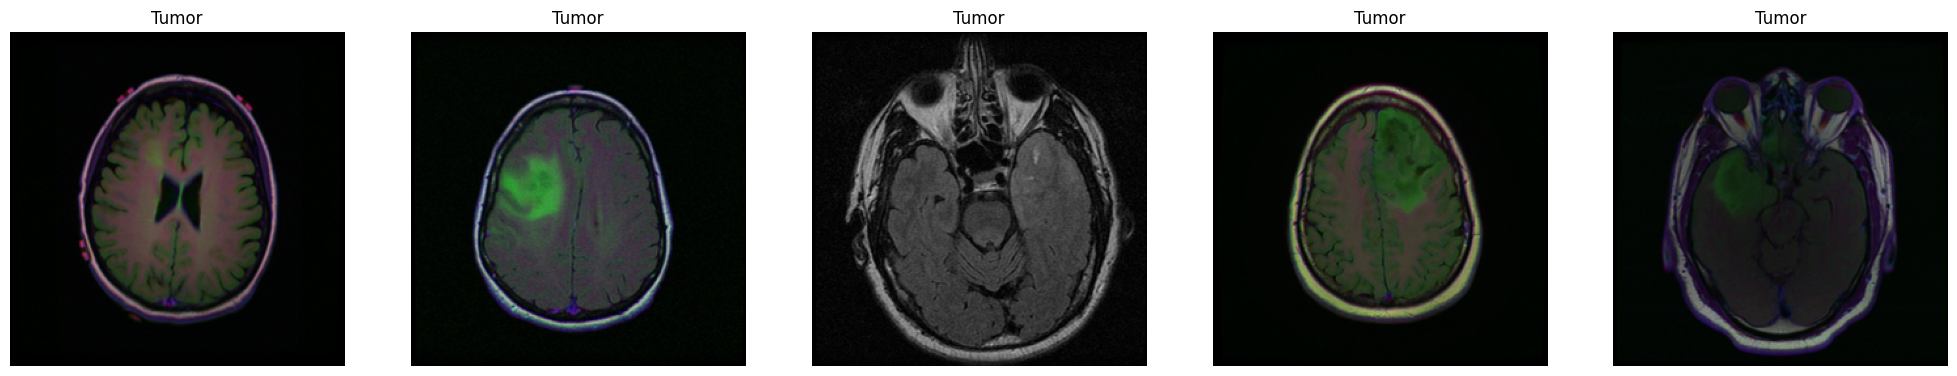

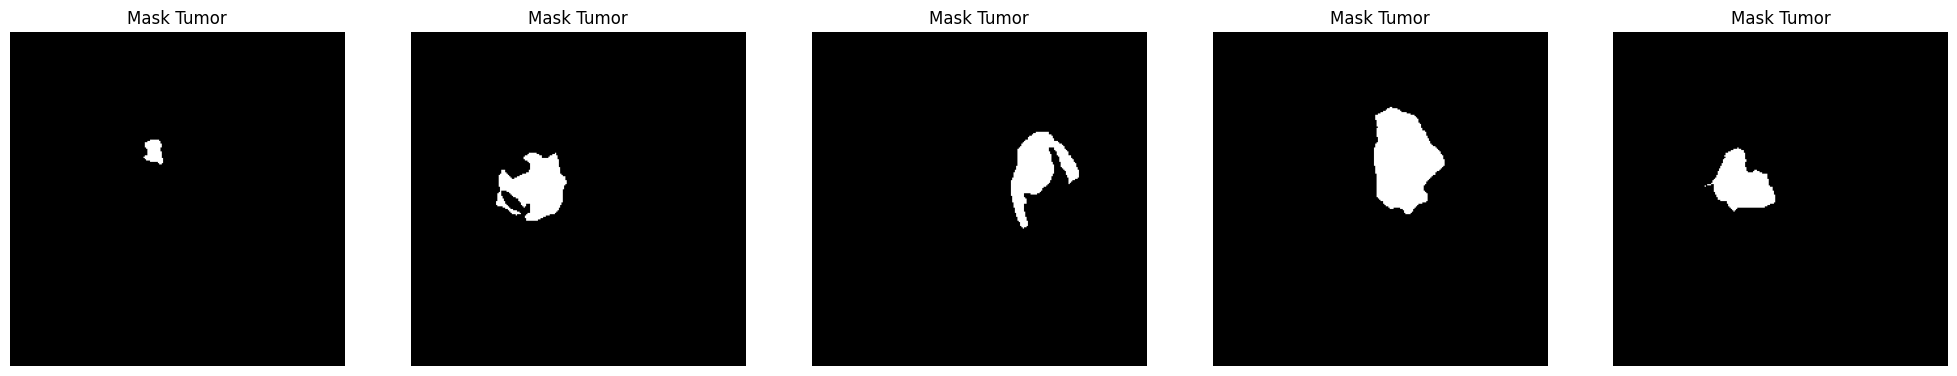

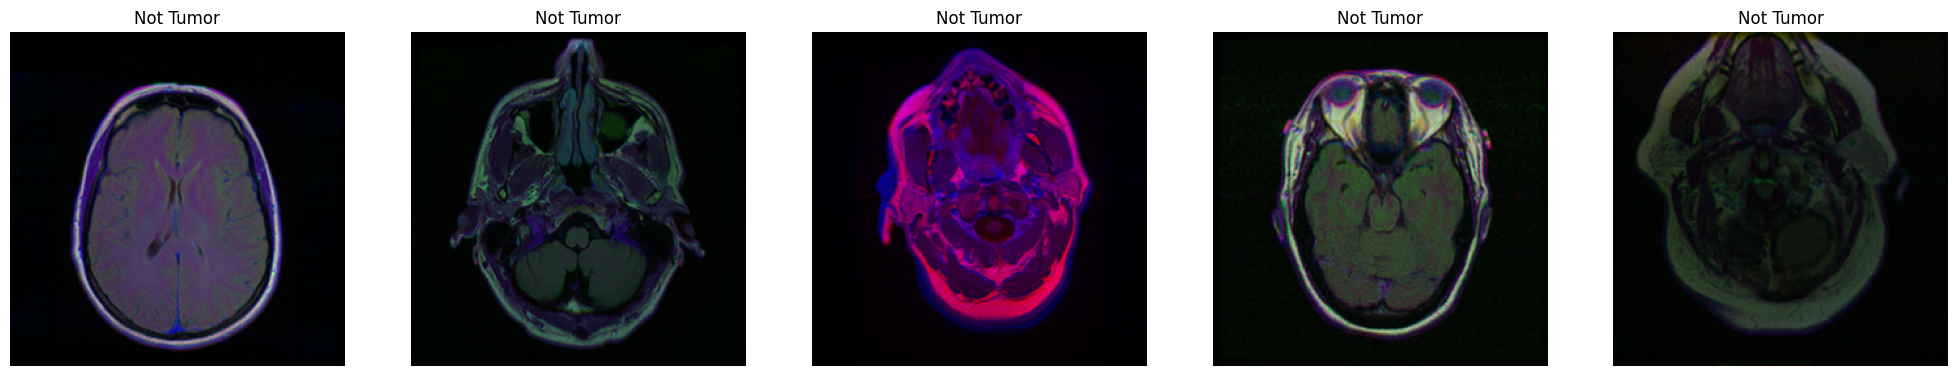

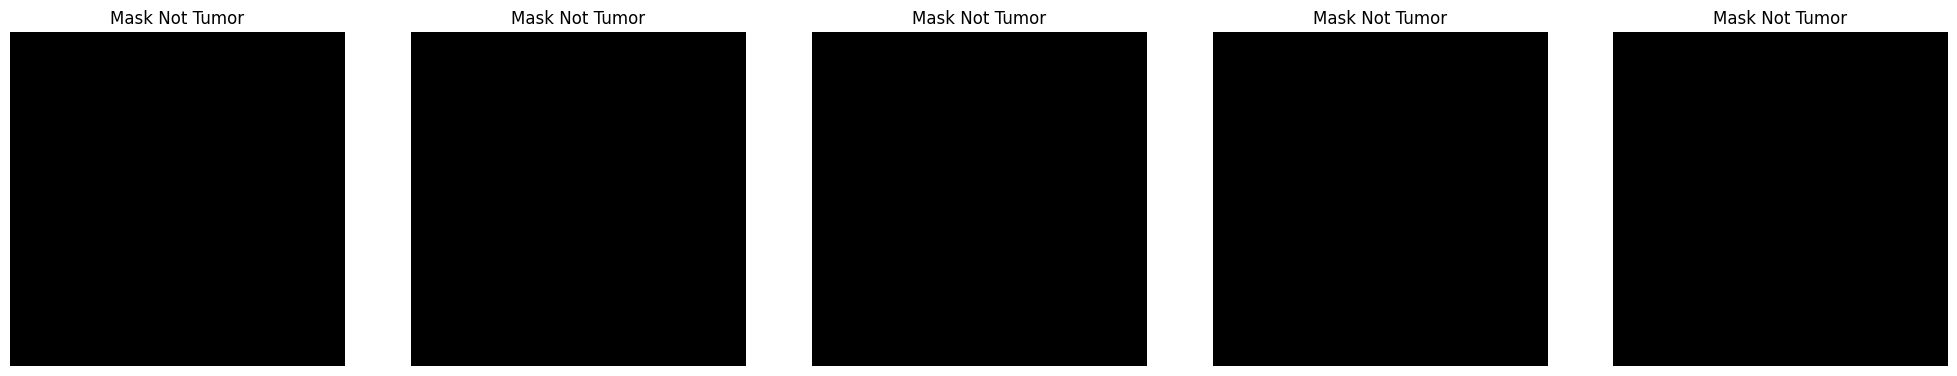

In [152]:
# Note: matplotlib and cv2 are already imported in earlier cells.

# ===== Settings =====
num_images = 8       # requested number of images to display
fig_width = 25       # figure width
fig_height = 8       # figure height

# Determine how many images are actually available (avoid index out of bounds)
available_tumor = df_Tumor.shape[0] if hasattr(df_Tumor, 'shape') else 0
available_not_tumor = df_NotTumor.shape[0] if hasattr(df_NotTumor, 'shape') else 0
n_display = min(num_images, available_tumor, available_not_tumor)

if n_display == 0:
    print("No images available to display.")
else:
    # ===== Tumor Images =====
    plt.figure(figsize=(fig_width, fig_height))
    for n in range(n_display):
        plt.subplot(1, n_display, n + 1)
        img = cv2.imread(df_Tumor[n, 0])
        if img is None:
            img = np.zeros((Size[0], Size[1], 3), dtype=np.uint8)
        else:
            # convert BGR (cv2) to RGB for correct colors in matplotlib
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.title('Tumor')
        plt.imshow(img)
        plt.axis('off')
    plt.show()

    # ===== Tumor Masks =====
    plt.figure(figsize=(fig_width, fig_height))
    for n in range(n_display):
        plt.subplot(1, n_display, n + 1)
        mask = cv2.imread(df_Tumor[n, 1], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((Size[0], Size[1]), dtype=np.uint8)
        plt.title('Mask Tumor')
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
    plt.show()

    # ===== Not Tumor Images =====
    plt.figure(figsize=(fig_width, fig_height))
    for n in range(n_display):
        plt.subplot(1, n_display, n + 1)
        img = cv2.imread(df_NotTumor[n, 0])
        if img is None:
            img = np.zeros((Size[0], Size[1], 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.title('Not Tumor')
        plt.imshow(img)
        plt.axis('off')
    plt.show()

    # ===== Not Tumor Masks =====
    plt.figure(figsize=(fig_width, fig_height))
    for n in range(n_display):
        plt.subplot(1, n_display, n + 1)
        mask = cv2.imread(df_NotTumor[n, 1], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((Size[0], Size[1]), dtype=np.uint8)
        plt.title('Mask Not Tumor')
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
    plt.show()

In [153]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.1)
df_test, df_val = train_test_split(df_test, test_size=0.5)
print(df_train.values.shape)
print(df_val.values.shape)
print(df_test.values.shape)

(3536, 3)
(197, 3)
(196, 3)


In [154]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def adjust_data(img, mask):
    img = img.astype("float32") / 255.0
    mask = mask.astype("float32") / 255.0

    # Binarisation des masques
    mask[mask > 0.5] = 1.0
    mask[mask <= 0.5] = 0.0

    return img, mask

def train_generator(
    data_frame,
    batch_size,
    aug_dict,
    image_color_mode="rgb",
    mask_color_mode="grayscale",
    image_save_prefix="image",
    mask_save_prefix="mask",
    save_to_dir=None,
    target_size=(256, 256),
    seed=1
):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow_from_dataframe(
        dataframe=data_frame,
        x_col="image",
        y_col=None,
        class_mode=None,
        color_mode=image_color_mode,
        target_size=target_size,
        batch_size=batch_size,
        save_to_dir=save_to_dir,
        save_prefix=image_save_prefix,
        shuffle=True,
        seed=seed,
    )

    mask_generator = mask_datagen.flow_from_dataframe(
        dataframe=data_frame,
        x_col="mask",
        y_col=None,
        class_mode=None,
        color_mode=mask_color_mode,
        target_size=target_size,
        batch_size=batch_size,
        save_to_dir=save_to_dir,
        save_prefix=mask_save_prefix,
        shuffle=True,
        seed=seed,
    )

    train_gen = zip(image_generator, mask_generator)

    for img, mask in train_gen:
        img, mask = adjust_data(img, mask)
        yield img, mask


In [155]:
def unet(input_size = (256,256,3)):
    inputs = Input(input_size)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)

    up6 = Conv2D(512, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(drop5))
    
    merge6 = concatenate([drop4,up6], axis = 3)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv6)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv6))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv1,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)
    conv10 = Conv2D(1, 1, activation = 'sigmoid')(conv9)

    model = Model(inputs= inputs, outputs = conv10)
    return model

In [156]:
m=unet()
m.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_276 (Conv2D) │ (None, 256, 256,  │      1,792 │ input_layer_12[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_277 (Conv2D) │ (None, 256, 256,  │     36,928 │ conv2d_276[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_48    │ (None, 128, 128,  │          0 │ conv2d_277[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_278 (Conv2D) │ (None, 128, 128,  │     73,856 │ max_pooling2d_48… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_279 (Conv2D) │ (None, 128, 128,  │    147,584 │ conv2d_278[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_49    │ (None, 64, 64,    │          0 │ conv2d_279[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_280 (Conv2D) │ (None, 64, 64,    │    295,168 │ max_pooling2d_49… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_281 (Conv2D) │ (None, 64, 64,    │    590,080 │ conv2d_280[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_50    │ (None, 32, 32,    │          0 │ conv2d_281[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_282 (Conv2D) │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_50… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_283 (Conv2D) │ (None, 32, 32,    │  2,359,808 │ conv2d_282[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 32, 32,    │          0 │ conv2d_283[0][0]  │
│ (Dropout)           │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_51    │ (None, 16, 16,    │          0 │ dropout_24[0][0]  │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_284 (Conv2D) │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_51… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_285 (Conv2D) │ (None, 16, 16,    │  9,438,208 │ conv2d_284[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 16, 16,    │          0 │ conv2d_285[0][0]

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [157]:
from tensorflow.keras import backend as K
import tensorflow as tf

smooth = 1e-6  # petite constante de stabilité numérique

def dice_coef(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, "float32"))
    y_pred = K.flatten(K.cast(y_pred, "float32"))
    intersection = K.sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

def dice_coef_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

_bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def bce_dice_loss(y_true, y_pred):
    return _bce(y_true, y_pred) + dice_coef_loss(y_true, y_pred)

def iou(y_true, y_pred):
    y_true = K.flatten(K.cast(y_true, "float32"))
    y_pred = K.flatten(K.cast(y_pred, "float32"))
    intersection = K.sum(y_true * y_pred)
    total = K.sum(y_true) + K.sum(y_pred)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)


In [158]:
EPOCHS = 50
BATCH_SIZE = 16
learning_rate = 1e-4

In [159]:
train_generator_args = dict(rotation_range=0.1,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=True,
                            vertical_flip=True,
                            fill_mode='nearest')
train_gen = train_generator(
    df_train,
    batch_size=BATCH_SIZE,
    aug_dict=train_generator_args,
    target_size=Size
)

val_gen = train_generator(
    df_val,
    batch_size=BATCH_SIZE,
    aug_dict=dict(rescale=1.0),  # ou {} si tu veux aucune aug
    target_size=Size
)

x_batch, y_batch = next(train_gen)
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("x dtype:", x_batch.dtype, "y dtype:", y_batch.dtype)
print("min/max mask:", y_batch.min(), y_batch.max())

    

Found 3536 validated image filenames.
Found 3536 validated image filenames.
x_batch shape: (16, 256, 256, 3)
y_batch shape: (16, 256, 256, 1)
x dtype: float32 y dtype: float32
min/max mask: 0.0 1.0


In [160]:
model = unet(input_size=(Size[0], Size[1], 3))

In [161]:
opt = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=None, amsgrad=False)

# use the .keras extension (Keras SavedModel format) to avoid the ValueError
callbacks = [ModelCheckpoint('brainMRI_Segment.keras', verbose=0, save_best_only=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-11),
            EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=15)]

In [162]:
model.compile(
    optimizer=opt,
    loss=bce_dice_loss,
    metrics=[iou, dice_coef]
)

In [164]:
import math

# use ceil to ensure we cover all samples
steps_per_epoch = max(1, math.ceil(len(df_train) / BATCH_SIZE))
validation_steps = max(1, math.ceil(len(df_val) / BATCH_SIZE))

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    callbacks=callbacks,
    validation_data=val_gen,
    validation_steps=validation_steps
    # workers=4,
    # use_multiprocessing=False
)


Epoch 1/50


ValueError: None values not supported.

In [ ]:
plt.figure(figsize=(8,15))
plt.subplot(3,1,1)
plt.plot(model.history.history['loss'], 'b-', label='train_loss')
plt.plot(model.history.history['val_loss'], 'r-', label='val_loss')
plt.legend(loc='best')
plt.title('Loss')

plt.subplot(3,1,2)
plt.plot(model.history.history['iou'], 'b-', label='train_iou')
plt.plot(model.history.history['val_iou'], 'r-', label='val_iou')
plt.legend(loc='best')
plt.title('IoU')

plt.subplot(3,1,3)
plt.plot(model.history.history['dice_coef'], 'b-', label='train_dice_coef')
plt.plot(model.history.history['val_dice_coef'], 'r-', label='val_dice_coef')
plt.legend(loc='best')
plt.title('Dice Coef')

In [ ]:
test_gen = train_generator(df_test, BATCH_SIZE,
                                dict(),
                                target_size=Size)
results = model.evaluate(test_gen, steps=len(df_test) / BATCH_SIZE)
print("Test IOU: ",results[1])
print("Test Dice Coefficent: ",results[2])

Found 196 validated image filenames.
Found 196 validated image filenames.


TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
for i in range(10):
    index=np.random.randint(1,len(df_test.index))
    img = cv2.imread(df_test['image'].iloc[index])
    img = cv2.resize(img ,Size)
    img = img / 255
    img = img[np.newaxis, :, :, :]
    pred=model.predict(img)

    plt.figure(figsize=(12,12))
    plt.subplot(1,3,1)
    plt.imshow(np.squeeze(img))
    plt.title('Original Image')
    plt.subplot(1,3,2)
    plt.imshow(np.squeeze(cv2.imread(df_test['mask'].iloc[index])))
    plt.title('Original Mask')
    plt.subplot(1,3,3)
    plt.imshow(np.squeeze(pred) > .5)
    plt.title('Prediction')
    plt.show()